In [49]:
# --- IMPORT STATEMENTS ---
import numpy as np
import healpy as hp

import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS

In [50]:
# --- GLOBAL VARIABLES ---

LINUX_DIRECTORY = "/home/aimee/mphys" # Aimee
EFFLESBERG_DIR = f'{LINUX_DIRECTORY}/data/maps' # Aimee
FIGURE_SAVEDIR = "figures/masking" # Aimee
CSV_SAVEDIR = f'{LINUX_DIRECTORY}/data'
# LINUX_DIRECTORY = "/home/u20482jg/MPHYS_Project_Local/"
# EFFLESBERG_DIR = f'{LINUX_DIRECTORY}/data/all_maps/maps' # Joe
# FIGURE_SAVEDIR = "figures/masking" # Joe

SAVE_FIGS = False

# Get precise values! these were eyeballed
L_BOUNDS = [0, 65] # degrees
B_BOUNDS = [-5, 5] # degrees

EFFELSBERG_MAPS = {
    "Effelsberg 1.43 GHz (10')":"EFFELSBERG-1.4285714285714286GHz-10.0amin.fits",
    "Effelsberg 1.43 GHz (15')":"EFFELSBERG-1.4285714285714286GHz-15.0amin.fits",
    "Effelsberg 1.43 GHz (20')":"EFFELSBERG-1.4285714285714286GHz-20.0amin.fits",
    "Effelsberg 1.43 GHz (25')":"EFFELSBERG-1.4285714285714286GHz-25.0amin.fits",
    "Effelsberg 1.43 GHz (30')":"EFFELSBERG-1.4285714285714286GHz-30.0amin.fits",
    "Effelsberg 1.43 GHz (60')":"EFFELSBERG-1.4285714285714286GHz-60.0amin.fits",
    "Effelsberg 2.73 GHz (5')":"EFFELSBERG-2.7272727272727275GHz-5.0amin.fits",
    "Effelsberg 2.73 GHz (10')":"EFFELSBERG-2.7272727272727275GHz-10.0amin.fits",
    "Effelsberg 2.73 GHz (15')":"EFFELSBERG-2.7272727272727275GHz-15.0amin.fits",
    "Effelsberg 2.73 GHz (20')":"EFFELSBERG-2.7272727272727275GHz-20.0amin.fits",
    "Effelsberg 2.73 GHz (25')":"EFFELSBERG-2.7272727272727275GHz-25.0amin.fits",
    "Effelsberg 2.73 GHz (30')":"EFFELSBERG-2.7272727272727275GHz-30.0amin.fits",
    "Effelsberg 2.73 GHz (60')":"EFFELSBERG-2.7272727272727275GHz-60.0amin.fits"
}
EFFELSBERG_KEYS = list(EFFELSBERG_MAPS.keys())
# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index

In [51]:
# --- FUNCTION DEFINITIONS ----

In [52]:
def get_map(path):
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data # convert to mK
    header = fits_file[0].header
    wcs = WCS(header)
 
    return data, header, wcs

In [53]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = -0.01 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if SAVE_FIGS:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [54]:
def split_diameter(diameter_str):
    
    try: # x and y the same (circle)
        diameter = (float(diameter_str), float(diameter_str))
    except ValueError: # x and y different (ellipse) - separated by 'x'
        temp = diameter_str.split('x')
        diameter = (float(temp[0]), float(temp[1]))

    return diameter

In [55]:
def read_snr_catalogue_simple(file_path, include_uncertain=True):
    # From D. A. Green SNR Catalogue: https://www.mrao.cam.ac.uk/surveys/snrs/snrs.data.html

    x_coords = [] # galactic coords - l
    y_coords = [] # galactic coords - b
    diameters = [] # arcmin (diameter, not radius - see documentation on website)

    with open(file_path, 'r') as file:
        for i, line in enumerate(file):
            if i > 2: # skip headers
                valid = True
                arr = line.split()
            
                x_coord = float(arr[0])

                y_coord = float(arr[1])
                
                diameter_str = arr[7] 
                if '?' in diameter_str: 
                    if include_uncertain:
                        diameter = split_diameter(diameter_str.replace('?', '')) 
                    else:
                        # print(f'Line {i} contains uncertain diameter - skipping line')
                        valid = False
                else:
                    diameter = split_diameter(diameter_str)
        
                if valid:
                    x_coords.append(x_coord)
                    y_coords.append(y_coord)
                    diameters.append(diameter)
    
    return x_coords, y_coords, diameters

In [56]:
def read_snr_catalogue(file_path, include_uncertain=True):
    # From D. A. Green SNR Catalogue: https://www.mrao.cam.ac.uk/surveys/snrs/snrs.data.html

    x_coords = [] # galactic coords - l
    y_coords = [] # galactic coords - b
    diameters = [] # arcmin (diameter, not radius - see documentation on website)
    fluxes_1GHz = [] # Jy
    spectral_indices = []

    with open(file_path, 'r') as file:
        for i, line in enumerate(file):
            if i > 2: # skip headers
                valid = True
                arr = line.split()
            
                x_coord = float(arr[0])

                y_coord = float(arr[1])
                
                diameter_str = arr[7] 
                if '?' in diameter_str: 
                    if include_uncertain:
                        diameter = split_diameter(diameter_str.replace('?', '')) 
                    else:
                        # print(f'Line {i} contains uncertain diameter - skipping line')
                        valid = False
                else:
                    diameter = split_diameter(diameter_str)
                
                flux_1GHz_str = arr[9]
                if flux_1GHz_str == '?':
                    # print(f'Line {i} contains no flux - skipping line')
                    valid = False
                elif ('<' in flux_1GHz_str) or ('>' in flux_1GHz_str): # I hate this catalogue so much
                    # print(f'Line {i} contains flux with inequality - skipping line')
                    valid = False
                elif '?' in flux_1GHz_str:
                    if include_uncertain:
                        flux_1GHz = float(flux_1GHz_str.replace('?', ''))
                    else:
                        # print(f'Line {i} contains uncertain flux - skipping line')
                        valid = False
                else:
                    flux_1GHz = float(flux_1GHz_str)

                spectral_index_str = arr[10]
                if (spectral_index_str == '?') or (spectral_index_str == 'varies'):
                    # print(f'Line {i} contains no/varying spectral index - skipping line')
                    valid = False
                elif '?' in spectral_index_str:
                    if include_uncertain:
                        spectral_index = float(spectral_index_str.replace('?', ''))
                    else:
                        # print(f'Line {i} contains uncertain spectral index - skipping line')
                        valid = False
                else:
                    spectral_index = float(spectral_index_str)
                
                if valid:
                    x_coords.append(x_coord)
                    y_coords.append(y_coord)
                    diameters.append(diameter)
                    fluxes_1GHz.append(flux_1GHz)
                    spectral_indices.append(spectral_index)


    return x_coords, y_coords, diameters, fluxes_1GHz, spectral_indices


In [57]:
def convert_flux(flux_1, spectral_index, frequency_1, frequency_2):

    flux_2 = flux_1 * (frequency_2 / frequency_1)**spectral_index

    return flux_2

In [58]:
def convert_snr_coords(x_coords, y_coords, WCS):

    x_min, y_min = WCS.all_world2pix(float(L_BOUNDS[0]), float(B_BOUNDS[0]), 0)
    x_max, y_max = WCS.all_world2pix(float(L_BOUNDS[1]), float(B_BOUNDS[1]), 0)

    x_coords_new = []
    y_coords_new = []
    for i, _ in enumerate(x_coords):
        l = x_coords[i] 
        b = y_coords[i]
        x, y = WCS.all_world2pix(float(l), float(b), 0)

        # only append if in range
        if (x < x_min) & (x > x_max) & (y > y_min) & (y < y_max): # x inequalities flipped because axis reversed
            x_coords_new.append(x)
            y_coords_new.append(y)
    
    return x_coords_new, y_coords_new

In [59]:
def main():
    
    # Read and plot Efflesberg
    map_name = EFFELSBERG_MAPS["Effelsberg 2.73 GHz (5')"]
    map_path = f'{EFFLESBERG_DIR}/{map_name}'
    data, header, wcs = get_map(map_path)
    plot_fits(data, wcs, title="Effelsberg 2.73 GHz (5')")

    # Read in data from D A Green SNR catalogue (.txt file)
    l_snr, b_snr, diameters, fluxes_1GHz, spectral_indices = read_snr_catalogue(file_path=f'{LINUX_DIRECTORY}/data/SNR_Catalogue_DAGreen.txt', include_uncertain=True)
    
    diameter_l = [d[0] for d in diameters]
    diameter_b = [d[1] for d in diameters]
    data_arr = np.array([l_snr, b_snr, diameter_l, diameter_b, fluxes_1GHz, spectral_indices]).T
    
    # # Cut SNR list to l and b range (see global variablescod)
    # temp = []
    # for row in data_arr:
    #     l = row[0]
    #     b = row[1]
    #     if (l < L_BOUNDS[1]) & (l > L_BOUNDS[0]) & (b > B_BOUNDS[0]) & (b < B_BOUNDS[1]): # x inequalities flipped because axis reversed
    #         temp.append(row)
    # data_arr = np.array(temp)

    # Exclude SNRs with fluxes (at 30GHz) < threshold (found by eye to be ~5.5 Jy @ 30 GHz (see W5 Thursday))
    temp = []
    for row in data_arr:
        flux_1GHz = row[4]
        spectral_index = row[5]
        flux_30GHz = convert_flux(flux_1GHz, spectral_index, 1e9, 30e9)
        if flux_30GHz > 5.5:
            row = [row[0], row[1], row[2], row[3], flux_30GHz, spectral_index]
            temp.append(row)
    data_arr_cut = np.array(temp)

    # Plot on map and print info
    
    print(f'{len(data_arr_cut)} SNR with valid frequency/spectral index found in range.')
    print('Coordinates (l, b) [degrees], diameters (l, b) [arcmin], flux @ 30 GHz [Jy], spectral index')
    for i, line in enumerate(data_arr_cut):
        print(f'SNR {i+1}: ({line[0]}, {line[1]}), ({line[2]}, {line[3]}), {line[4]}, {line[5]}')

    x_snr, y_snr = convert_snr_coords(data_arr[:,0], data_arr[:,1], wcs)
    plot_fits(data, wcs, x_coords=x_snr, y_coords=y_snr, title="Effelsberg 2.73 GHz (5') - SNR Locations (valid flux/spectral index)") 

    # Save to csv
    file_out = f'{CSV_SAVEDIR}/SNR_locations_final.csv'
    header = ['l [degrees], b [degrees], x diameter [arcmin], y diameter [arcmin], flux @ 30 GHz [Jy], spectral index']
    with open(file_out, 'w') as f:
        f.write(','.join(header) + '\n')
        np.savetxt(f, data_arr_cut, delimiter=',', fmt='%s')
    print(f'File saved as {file_out}')



Getting data from /home/aimee/mphys/data/maps/EFFELSBERG-2.7272727272727275GHz-5.0amin.fits


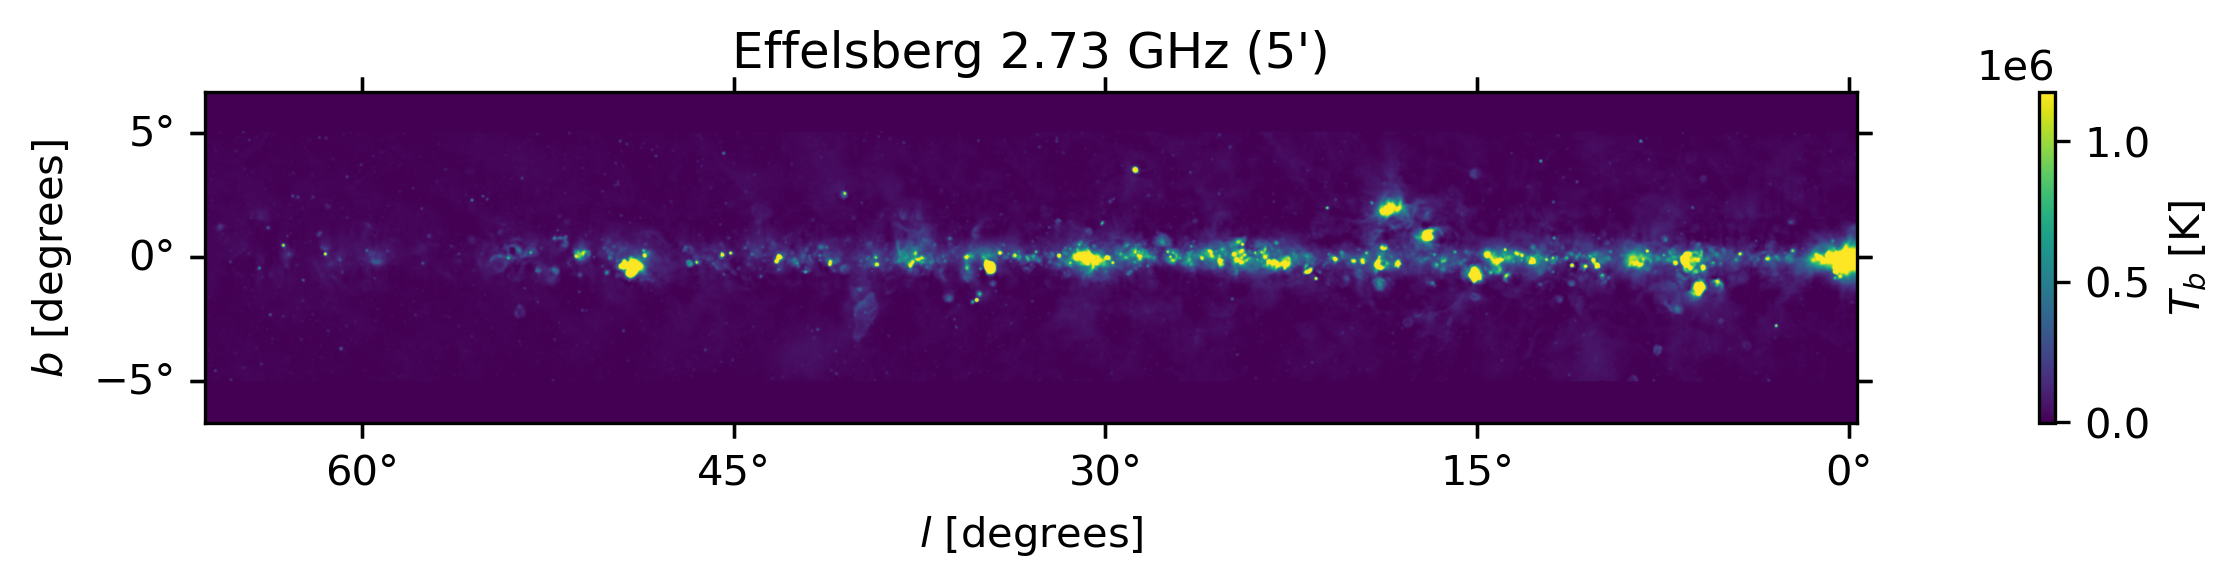

203 SNR with valid frequency/spectral index found in range.
Coordinates (l, b) [degrees], diameters (l, b) [arcmin], flux @ 30 GHz [Jy], spectral index
SNR 1: (0.0, 0.0), (3.5, 2.5), 1519.4870523363547, 0.8
SNR 2: (0.3, 0.0), (15.0, 8.0), 169.31499949597372, 0.6
SNR 3: (1.0, -0.1), (8.0, 8.0), 115.44204511089117, 0.6
SNR 4: (3.1, -0.6), (52.0, 28.0), 106.75276526873981, 0.9
SNR 5: (3.7, -0.2), (14.0, 11.0), 20.98247196825186, 0.65
SNR 6: (3.8, 0.3), (18.0, 18.0), 23.088409022178233, 0.6
SNR 7: (4.2, -3.5), (28.0, 28.0), 24.62763629032345, 0.6
SNR 8: (4.5, 6.8), (3.0, 3.0), 167.53718111371577, 0.64
SNR 9: (4.8, 6.2), (18.0, 18.0), 23.088409022178233, 0.6
SNR 10: (5.2, -2.6), (18.0, 18.0), 20.009954485887803, 0.6
SNR 11: (5.4, -1.2), (35.0, 35.0), 69.1022670042187, 0.2
SNR 12: (5.5, 0.3), (15.0, 12.0), 59.4767963632158, 0.7
SNR 13: (5.9, 3.1), (20.0, 20.0), 12.863597475023425, 0.4
SNR 14: (6.1, 0.5), (18.0, 12.0), 96.07748874186584, 0.9
SNR 15: (6.1, 1.2), (30.0, 26.0), 11.09676445868872

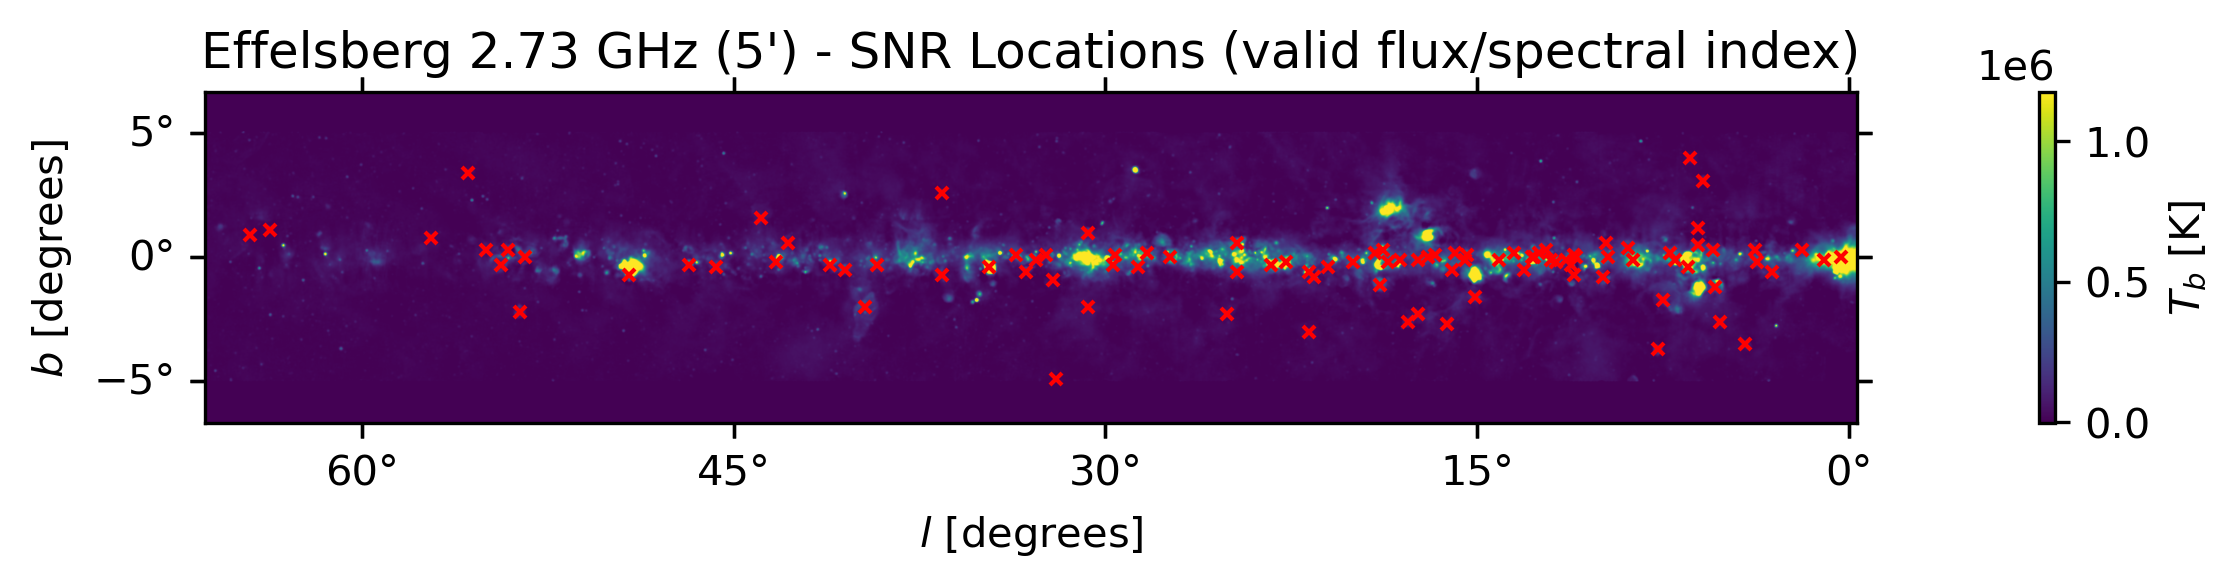

File saved as /home/aimee/mphys/data/SNR_locations_final.csv


In [60]:
main() # see Thursday week 5 for how I made the final list - saved as SNRs_final.csv (NOTE: different now using larger range - no eyeballing)